<a href="https://colab.research.google.com/github/Abdulwadud4/ACCESS-6.0-Data-Science-track/blob/main/capstone_logistics_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error #metrics to evaluate our models performance
insr = pd.read_csv("/content/insurance.csv")

In [3]:
insr.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insr.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
# craeting the target features
# Categorize charges into high paying and low paying
def categorize_charges(charges):
    if charges < 9000:
        return 'low paying'
    else:
        return 'high paying'

insr['charge_level'] = insr['charges'].apply(categorize_charges)

print(insr['charge_level'].value_counts())

charge_level
high paying    690
low paying     648
Name: count, dtype: int64


In [6]:
insr.head(10)

,age,sex,bmi,children,smoker,region,charges,charge_level
0,19,female,27.900,0,yes,southwest,16884.92400,high paying
1,18,male,33.770,1,no,southeast,1725.55230,low paying
2,28,male,33.000,3,no,southeast,4449.46200,low paying
3,33,male,22.705,0,no,northwest,21984.47061,high paying
4,32,male,28.880,0,no,northwest,3866.85520,low paying
5,31,female,25.740,0,no,southeast,3756.62160,low paying
6,46,female,33.440,1,no,southeast,8240.58960,low paying
7,37,female,27.740,3,no,northwest,7281.50560,low paying
8,37,male,29.830,2,no,northeast,6406.41070,low paying
9,60,female,25.840,0,no,northwest,28923.13692,high paying


In [7]:
insr.head(10)

,age,sex,bmi,children,smoker,region,charges,charge_level
0,19,female,27.900,0,yes,southwest,16884.92400,high paying
1,18,male,33.770,1,no,southeast,1725.55230,low paying
2,28,male,33.000,3,no,southeast,4449.46200,low paying
3,33,male,22.705,0,no,northwest,21984.47061,high paying
4,32,male,28.880,0,no,northwest,3866.85520,low paying
5,31,female,25.740,0,no,southeast,3756.62160,low paying
6,46,female,33.440,1,no,southeast,8240.58960,low paying
7,37,female,27.740,3,no,northwest,7281.50560,low paying
8,37,male,29.830,2,no,northeast,6406.41070,low paying
9,60,female,25.840,0,no,northwest,28923.13692,high paying


In [8]:
#check duplicate
insr.duplicated().sum()

np.int64(1)

In [9]:
# Remove duplicate rows
insr = insr.drop_duplicates()


print(f"Shape after removing duplicates: {insr.shape}")


Shape after removing duplicates: (1337, 8)


In [10]:
# craeting more features
# Categorize age into young, adults, grown adults, old, very old,
def categorize_age(age):
    if age < 30:
        return 'young'
    elif age < 40:
        return 'adults'
    elif age < 50:
        return 'grown adults'
    elif age < 60:
        return 'old'
    else:
        return 'very old'


insr['age_range'] = insr['age'].apply(categorize_age)

print(insr['age_range'].value_counts())

age_range
young           416
grown adults    279
old             271
adults          257
very old        114
Name: count, dtype: int64


In [11]:
insr.head(10)

,age,sex,bmi,children,smoker,region,charges,charge_level,age_range
0,19,female,27.900,0,yes,southwest,16884.92400,high paying,young
1,18,male,33.770,1,no,southeast,1725.55230,low paying,young
2,28,male,33.000,3,no,southeast,4449.46200,low paying,young
3,33,male,22.705,0,no,northwest,21984.47061,high paying,adults
4,32,male,28.880,0,no,northwest,3866.85520,low paying,adults
5,31,female,25.740,0,no,southeast,3756.62160,low paying,adults
6,46,female,33.440,1,no,southeast,8240.58960,low paying,grown adults
7,37,female,27.740,3,no,northwest,7281.50560,low paying,adults
8,37,male,29.830,2,no,northeast,6406.41070,low paying,adults
9,60,female,25.840,0,no,northwest,28923.13692,high paying,very old


In [12]:
print("TARGET VARIABLE ANALYSIS")

insr['charge_level'].value_counts(normalize = True)

TARGET VARIABLE ANALYSIS


,proportion
charge_level,
high paying,0.516081
low paying,0.483919


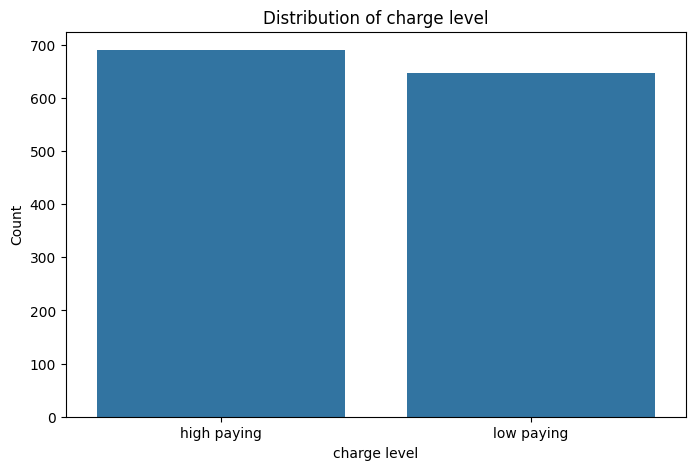

In [13]:
#Visualizing the Target Variable
plt.figure(figsize=(8, 5))
sns.countplot(data=insr, x='charge_level')
plt.title('Distribution of charge level')
plt.xlabel('charge level')
plt.ylabel('Count')
plt.show()

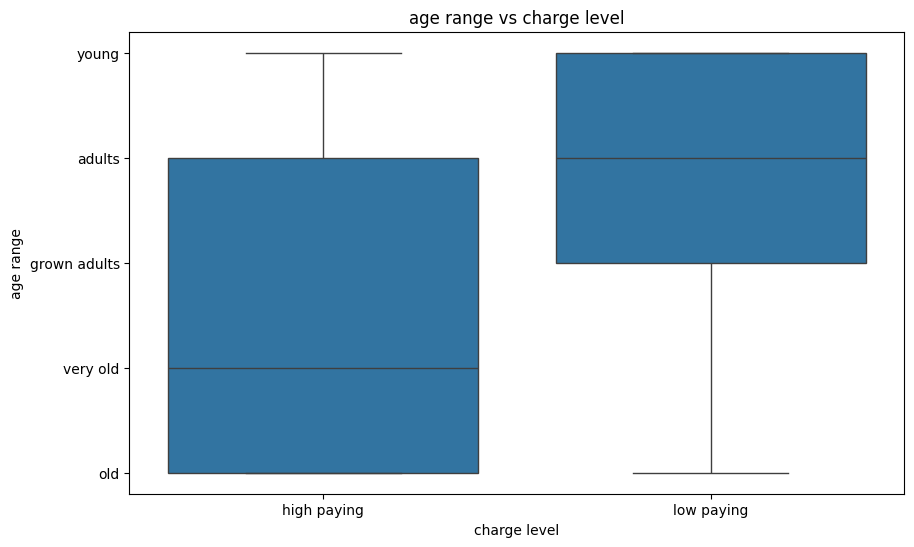

In [14]:
# age distribution by chages level

plt.figure(figsize=(10, 6))
sns.boxplot(data=insr, x='charge_level', y='age_range')
plt.title('age range vs charge level')
plt.xlabel('charge level')
plt.ylabel('age range')
plt.show()


In [15]:
#this shows that old people and the adults pay high insurance
#while the young (18 - 40) have low medical insurance pay

In [16]:
insr.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'charge_level', 'age_range'],
      dtype='object')

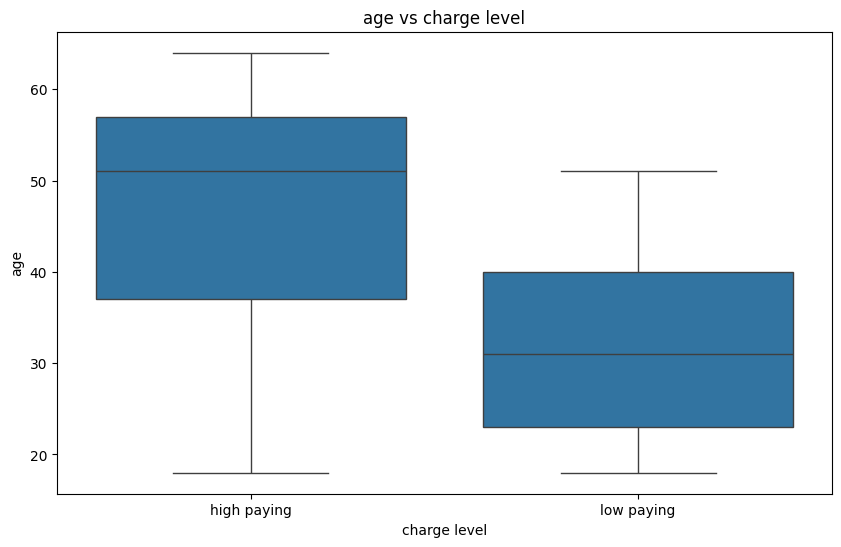

In [17]:
#age distribution with charge level
plt.figure(figsize=(10, 6))
sns.boxplot(data=insr, x='charge_level', y='age')
plt.title('age vs charge level')
plt.xlabel('charge level')
plt.ylabel('age')
plt.show()


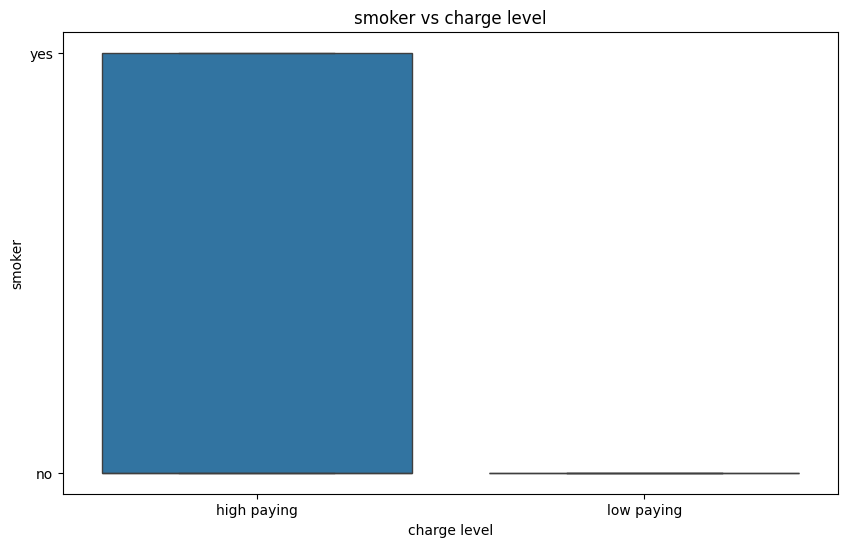

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=insr, x='charge_level', y='smoker')
plt.title('smoker vs charge level')
plt.xlabel('charge level')
plt.ylabel('smoker')
plt.show()


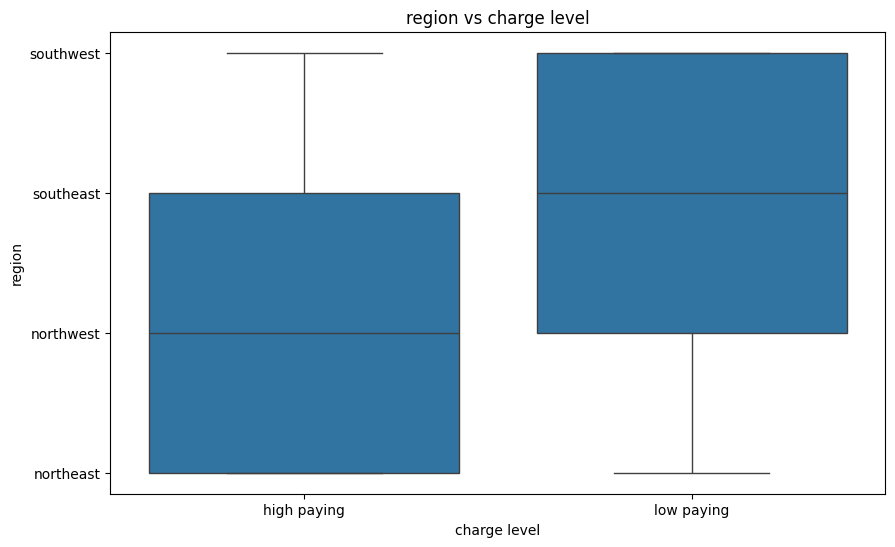

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=insr, x='charge_level', y='region')
plt.title('region vs charge level')
plt.xlabel('charge level')
plt.ylabel('region')
plt.show()


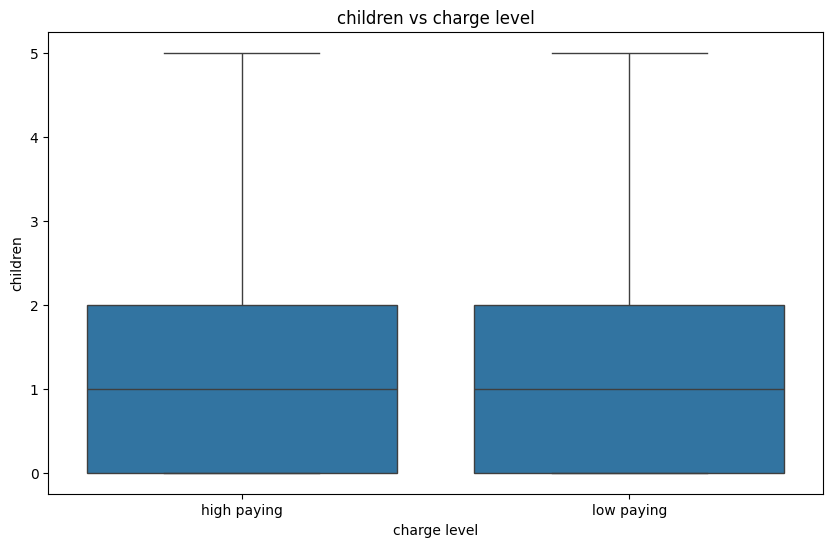

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=insr, x='charge_level', y='children')
plt.title('children vs charge level')
plt.xlabel('charge level')
plt.ylabel('children')
plt.show()


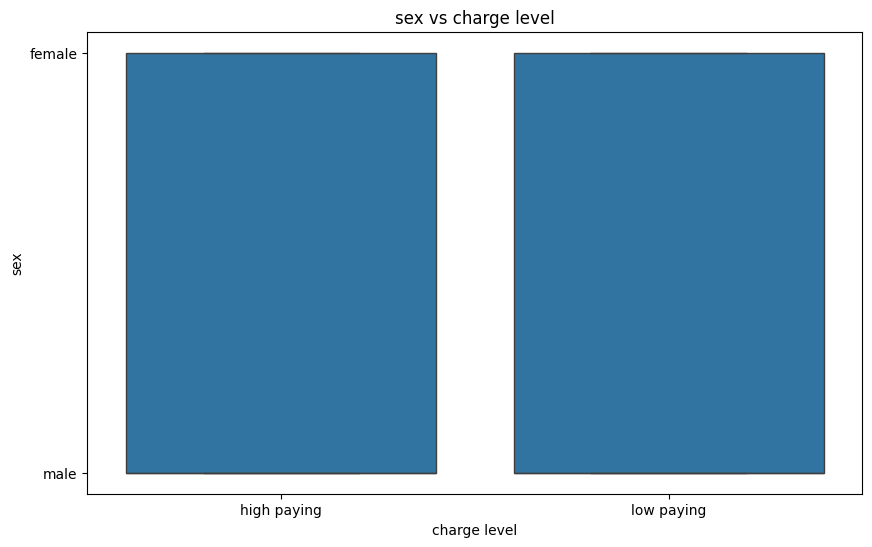

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=insr, x='charge_level', y='sex')
plt.title('sex vs charge level')
plt.xlabel('charge level')
plt.ylabel('sex')
plt.show()


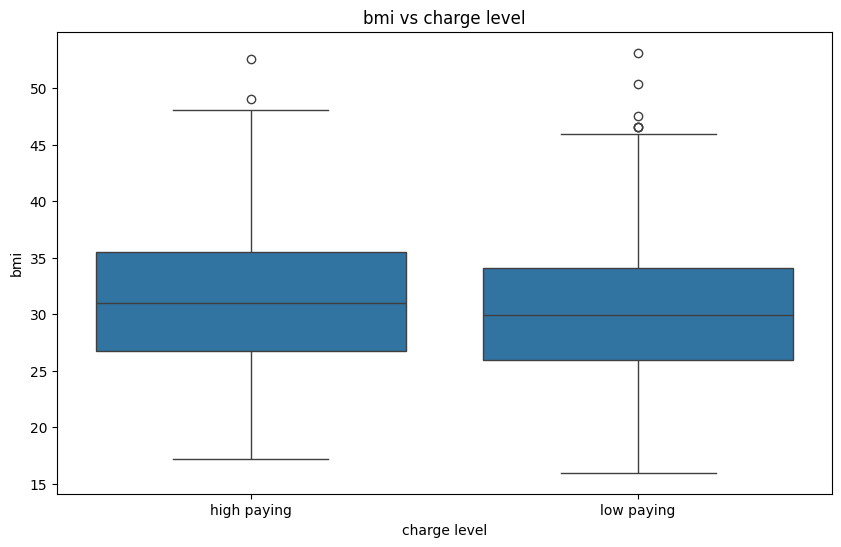

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=insr, x='charge_level', y='bmi')
plt.title('bmi vs charge level')
plt.xlabel('charge level')
plt.ylabel('bmi')
plt.show()


In [23]:
insr.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'charge_level', 'age_range'],
      dtype='object')

In [24]:
# Correlation analysis for numerical features
print("\nCorrelation with Loan Approval:")

# Map 'charge_level' to numerical values for correlation
charge_level_mapping = {'low paying': 0, 'high paying': 1}
insr['charge_level_numeric'] = insr['charge_level'].map(charge_level_mapping)

# Drop non-numeric or irrelevant columns before correlation with the target variable
# The .corrwith() method only works with numeric types.
# 'sex', 'smoker', 'region', 'age_range' are categorical and need one-hot encoding if their correlation is needed directly.
# 'charges' is the original numerical column, so it can't be correlated with its own derived 'charge_level_numeric' in this context.
# We are interested in how other features correlate with 'charge_level_numeric'.

# Select only numerical features and the newly created numeric target for correlation
numerical_features = ['age', 'bmi', 'children']

# Create a temporary DataFrame with numerical features and the target for correlation
temp_df = insr[numerical_features].copy()
temp_df['charge_level_numeric'] = insr['charge_level_numeric']

correlations = temp_df.corrwith(insr['charge_level_numeric'])
print(correlations.sort_values(ascending=False))


Correlation with Loan Approval:
charge_level_numeric    1.000000
age                     0.533537
bmi                     0.083555
children                0.023524
dtype: float64


In [34]:
insr.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'charge_level', 'age_range', 'charge_level_numeric'],
      dtype='object')

In [42]:
#Separate X and y
X = insr.drop(['charge_level', 'charge_level_numeric'], axis=1)
y = insr['charge_level_numeric']  # Use the numeric target variable

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (1337, 8)
Target shape: (1337,)


In [43]:
X.head(10)

,age,sex,bmi,children,smoker,region,charges,age_range
0,19,female,27.900,0,yes,southwest,16884.92400,young
1,18,male,33.770,1,no,southeast,1725.55230,young
2,28,male,33.000,3,no,southeast,4449.46200,young
3,33,male,22.705,0,no,northwest,21984.47061,adults
4,32,male,28.880,0,no,northwest,3866.85520,adults
5,31,female,25.740,0,no,southeast,3756.62160,adults
6,46,female,33.440,1,no,southeast,8240.58960,grown adults
7,37,female,27.740,3,no,northwest,7281.50560,adults
8,37,male,29.830,2,no,northeast,6406.41070,adults
9,60,female,25.840,0,no,northwest,28923.13692,very old


In [44]:
y.head(10)

,charge_level_numeric
0,1
1,0
2,0
3,1
4,0
5,0
6,0
7,0
8,0
9,1


In [45]:
#Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Keep same proportion of approved/rejected in both sets
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (1069, 8)
Test set: (268, 8)


In [40]:
# Define preprocessor
numerical_cols = ['age', 'bmi', 'children', 'charges']
categorical_cols = ['sex', 'smoker', 'region', 'age_range']

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore') # handle_unknown='ignore' to prevent errors during prediction with unseen categories

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough' # Keep other columns (if any) that are not specified
)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Features scaled and encoded successfully!")
print(f"Original X_train shape: {X_train.shape}")
print(f"Processed X_train shape: {X_train_processed.shape}")


Features scaled and encoded successfully!
Original X_train shape: (1069, 8)
Processed X_train shape: (1069, 17)


In [47]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_processed, y_train)
print("Logistic Regression trained!")

# Make predictions
y_pred_log = log_reg.predict(X_test_processed)
print("Predictions made!")

Logistic Regression trained!
Predictions made!


In [49]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_clf.fit(X_train_processed, y_train)
print("Decision Tree trained!")

# Make predictions
y_pred_dt = dt_clf.predict(X_test_processed)
print("Predictions made!")

Decision Tree trained!
Predictions made!


In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_clf.fit(X_train_processed, y_train)
print("Random Forest trained!")

"""
Parameters explained:
- n_estimators=100: Build 100 trees
- max_depth=10: Each tree can ask up to 10 questions
- random_state=42: For reproducibility
"""

# Make predictions
y_pred_rf = rf_clf.predict(X_test_processed)
print("Predictions made!")

Random Forest trained!
Predictions made!


In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_model(model_name, y_test, y_pred):


    # Calculate all metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Print metrics
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

    '''print(f"\n{'-'*70}")
    print("WHAT THESE NUMBERS MEAN:")
    print(f"{'-'*70}")
    print(f"✓ Model got {accuracy*100:.2f}% of predictions correct")
    print(f"✓ Of approved loans, {precision*100:.2f}% were actually good")
    print(f"✓ Of good loans, we approved {recall*100:.2f}% of them")
    print(f"✓ F1-Score balances precision and recall: {f1*100:.2f}%")'''

    # Confusion Matrix
    print(f"\n{'-'*70}")
    print("CONFUSION MATRIX:")
    print(f"{'-'*70}")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    '''print(f"\nBreakdown:")
    print(f"  True Negatives (Correctly Rejected):  {cm[0][0]}")
    print(f"  False Positives (Wrongly Approved):   {cm[0][1]} ⚠️")
    print(f"  False Negatives (Wrongly Rejected):   {cm[1][0]} ⚠️")
    print(f"  True Positives (Correctly Approved):  {cm[1][1]}")'''

    # Classification Report
    print(f"\n{'-'*70}")
    print("DETAILED CLASSIFICATION REPORT:")
    print(f"{'-'*70}")
    print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

    # Return metrics as dictionary
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

In [56]:
#Evaluate each model using our function

# Evaluate Logistic Regression
log_reg_results = evaluate_model("Logistic Regression", y_test, y_pred_log)

# Evaluate Decision Tree
dt_results = evaluate_model("Decision Tree", y_test, y_pred_dt)

# Evaluate Random Forest
rf_results = evaluate_model("Random Forest", y_test, y_pred_rf)

Accuracy:  0.9776 (97.76%)
Precision: 0.9925 (99.25%)
Recall:    0.9638 (96.38%)
F1-Score:  0.9779 (97.79%)

----------------------------------------------------------------------
CONFUSION MATRIX:
----------------------------------------------------------------------
[[129   1]
 [  5 133]]

----------------------------------------------------------------------
DETAILED CLASSIFICATION REPORT:
----------------------------------------------------------------------
              precision    recall  f1-score   support

    Rejected       0.96      0.99      0.98       130
    Approved       0.99      0.96      0.98       138

    accuracy                           0.98       268
   macro avg       0.98      0.98      0.98       268
weighted avg       0.98      0.98      0.98       268

Accuracy:  1.0000 (100.00%)
Precision: 1.0000 (100.00%)
Recall:    1.0000 (100.00%)
F1-Score:  1.0000 (100.00%)

----------------------------------------------------------------------
CONFUSION MATRIX:
----

In [61]:
# Check 1: What are the shapes?
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Check 2: Look at a few predictions vs actual
print("\nFirst 20 predictions:")
print(y_pred_rf[:20])
print("\nFirst 20 actual values:")
print(y_test.values[:20])

# Check 3: Are they ALL correct?
print("\nNumber of correct predictions:", (y_pred_rf == y_test).sum())
print("Total predictions:", len(y_test))
print("Accuracy:", (y_pred_rf == y_test).sum() / len(y_test))

# Check 4: Class distribution
print("\nClass distribution in y_train:")
print(pd.Series(y_train).value_counts())
print("\nClass distribution in y_test:")
print(pd.Series(y_test).value_counts())

# Check 5: Look at the ORIGINAL X (before scaling) - what columns did it have?
print("\nOriginal X columns (before scaling):")
print(X.columns.tolist())

# Check 6: Does X still have 'charge_level' by accident?
if 'charge_level' in X.columns:
    print("\n⚠️ WARNING: 'charge_level' is still in your features! DATA LEAKAGE!")
else:
    print("\n✓ 'charge_level' not in features (good)")

X_train_processed shape: (1069, 17)
X_test_processed shape: (268, 17)
y_train shape: (1069,)
y_test shape: (268,)

First 20 predictions:
[0 0 0 1 0 0 0 1 1 1 1 1 1 0 0 1 0 0 1 0]

First 20 actual values:
[0 0 0 1 0 0 0 1 1 1 1 1 1 0 0 1 0 0 1 0]

Number of correct predictions: 268
Total predictions: 268
Accuracy: 1.0

Class distribution in y_train:
charge_level_numeric
1    552
0    517
Name: count, dtype: int64

Class distribution in y_test:
charge_level_numeric
1    138
0    130
Name: count, dtype: int64

Original X columns (before scaling):
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'age_range']

✓ 'charge_level' not in features (good)


In [67]:
# Let's start completely fresh and trace through everything

print("="*70)
print("STEP 1: CHECK ORIGINAL DATAFRAME")
print("="*70)
print("\nAll columns in insr:")
print(insr.columns.tolist())

print("\nDataFrame shape:", insr.shape)
print("\nFirst few rows:")
print(insr.head())

print("\n" + "="*70)
print("STEP 2: CHECK WHAT'S IN X AND y")
print("="*70)
print("\nColumns in X:")
print(X.columns.tolist())
print("\nX shape:", X.shape)

print("\nFirst row of X:")
print(X.iloc[0])

print("\ny unique values:", np.unique(y))
print("y value counts:")
print(pd.Series(y).value_counts())

print("\n" + "="*70)
print("STEP 3: CHECK CORRELATION")
print("="*70)
# Check if any feature is perfectly correlated with target
temp_insr = X.copy()
temp_insr['target'] = y

# Select only numerical columns from temp_insr for correlation calculation
# Use the predefined numerical_cols list from earlier cells, plus the 'target'
# The 'charges' column is intentionally included here to check for data leakage,
# as it's the basis for 'charge_level_numeric'.
features_to_correlate = [col for col in numerical_cols if col in temp_insr.columns] + ['target']

correlations = temp_insr[features_to_correlate].corr()['target'].sort_values(ascending=False)
print("\nCorrelation with target:")
print(correlations)

print("\n⚠️ If any feature has correlation = 1.0 or -1.0, that's data leakage!")

print("\n" + "="*70)
print("STEP 4: MANUAL PREDICTION TEST")
print("="*70)
# Let's manually check one prediction
print("\nFirst test sample (original values before scaling):")
print(X_test.iloc[0])
print("\nActual label:", y_test.iloc[0])
print("\nModel prediction:", y_pred_rf[0])
print("\nPrediction probability:", rf_clf.predict_proba(X_test_processed)[0])

STEP 1: CHECK ORIGINAL DATAFRAME

All columns in insr:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'charge_level', 'age_range', 'charge_level_numeric']

DataFrame shape: (1337, 10)

First few rows:
   age     sex     bmi  children smoker     region      charges charge_level  \
0   19  female  27.900         0    yes  southwest  16884.92400  high paying   
1   18    male  33.770         1     no  southeast   1725.55230   low paying   
2   28    male  33.000         3     no  southeast   4449.46200   low paying   
3   33    male  22.705         0     no  northwest  21984.47061  high paying   
4   32    male  28.880         0     no  northwest   3866.85520   low paying   

  age_range  charge_level_numeric  
0     young                     1  
1     young                     0  
2     young                     0  
3    adults                     1  
4    adults                     0  

STEP 2: CHECK WHAT'S IN X AND y

Columns in X:
['age', 'sex', 'bmi', 'children', 's